In [3]:
import pandas as pd
import numpy as np

master = pd.read_csv("../data/processed/master_ecommerce.csv", parse_dates=[
    'order_purchase_timestamp'
])

# Only use valid, completed orders for RFM (exclude cancelled)
rfm_data = master[master['order_status'] != 'canceled'].copy()

# Set a reference "snapshot" date — one day after the last order in the dataset
snapshot_date = rfm_data['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

# Recency: days since each customer's most recent purchase
recency = rfm_data.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
recency['recency'] = (snapshot_date - recency['order_purchase_timestamp']).dt.days
recency = recency[['customer_unique_id', 'recency']]

print(recency.head())
print(recency['recency'].describe())

Snapshot date: 2018-09-04 09:06:57
                 customer_unique_id  recency
0  0000366f3b9a7992bf8c76cfdf3221e2      116
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119
2  0000f46a3911fa3c0805444483337064      542
3  0000f6ccb0745a6a4b88665a16c9f078      326
4  0004aac84e0df4da2b147fca70cf8255      293
count    95560.000000
mean       244.034523
std        153.126177
min          1.000000
25%        120.000000
50%        225.000000
75%        353.000000
max        729.000000
Name: recency, dtype: float64


In [2]:
import pandas as pd
import numpy as np

master = pd.read_csv("../data/processed/master_ecommerce.csv", parse_dates=[
    'order_purchase_timestamp'
])
print(master.shape)

(99441, 23)


In [1]:
import pandas as pd
import numpy as np

master = pd.read_csv("../data/processed/master_ecommerce.csv", parse_dates=[
    'order_purchase_timestamp'
])
print(master.shape)

(99441, 23)


In [4]:
# Frequency: number of distinct orders per customer
frequency = rfm_data.groupby('customer_unique_id')['order_id'].nunique().reset_index()
frequency.columns = ['customer_unique_id', 'frequency']

# Monetary: total amount spent per customer
monetary = rfm_data.groupby('customer_unique_id')['total_price'].sum().reset_index()
monetary.columns = ['customer_unique_id', 'monetary']

print(frequency['frequency'].describe())
print(monetary['monetary'].describe())

count    95560.000000
mean         1.034073
std          0.212154
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: frequency, dtype: float64
count    95560.000000
mean       141.234915
std        215.728209
min          0.000000
25%         46.400000
50%         89.000000
75%        154.000000
max      13440.000000
Name: monetary, dtype: float64


In [5]:
# Merge R, F, M into one table
rfm = recency.merge(frequency, on='customer_unique_id').merge(monetary, on='customer_unique_id')

# Score each metric 1-5 using quantiles
# Recency: lower days = better, so we reverse the labels (5 = most recent)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency: mostly all 1s here, so we handle it with rank-based binning to avoid errors
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Monetary: higher spend = better
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine into a single RFM score string, e.g. "543"
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head(10))

                 customer_unique_id  recency  frequency  monetary R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1    129.90       4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1     18.90       4   
2  0000f46a3911fa3c0805444483337064      542          1     69.00       1   
3  0000f6ccb0745a6a4b88665a16c9f078      326          1     25.99       2   
4  0004aac84e0df4da2b147fca70cf8255      293          1    180.00       2   
5  0004bd2a26a76fe21f786e4fbd80607f      151          1    154.00       4   
6  00050ab1314c0e55a6ca13cf7181fecf      136          1     27.99       4   
7  00053a61a98854899e70ed204dd4bafe      187          1    382.00       3   
8  0005e1862207bf6ccc02e4228effd9a0      548          1    135.00       1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      175          1    104.90       4   

  F_score M_score RFM_score  
0       1       4       414  
1       1       1       411  
2       1       2       112  
3       1       1       211  
4 

In [6]:
def rfm_segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

segment_summary = rfm['segment'].value_counts().reset_index()
segment_summary.columns = ['segment', 'customer_count']
segment_summary['pct'] = (segment_summary['customer_count'] / segment_summary['customer_count'].sum() * 100).round(1)

print(segment_summary)

           segment  customer_count   pct
0  Loyal Customers           27963  29.3
1          At Risk           22760  23.8
2  Needs Attention           16413  17.2
3    New Customers           15351  16.1
4        Champions            6613   6.9
5             Lost            6460   6.8


C:\Users\Anuj Diwakar\AppData\Local\Temp\ipykernel_2284\860310921.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='customer_count', y='segment', palette='rocket')


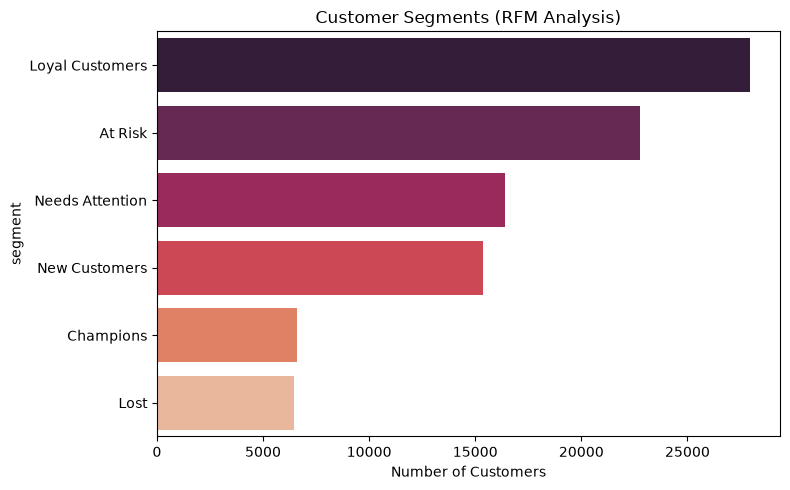

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(data=segment_summary, x='customer_count', y='segment', palette='rocket')
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

C:\Users\Anuj Diwakar\AppData\Local\Temp\ipykernel_2284\2926847752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='customer_count', y='segment', palette='rocket')


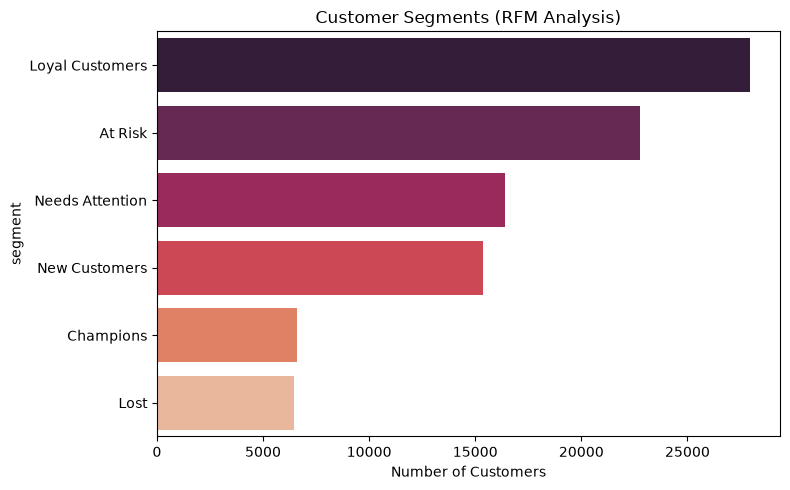

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(data=segment_summary, x='customer_count', y='segment', palette='rocket')
plt.title('Customer Segments (RFM Analysis)')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.show()

In [10]:
import os
os.makedirs("../data/processed", exist_ok=True)
rfm.to_csv("../data/processed/rfm_segments.csv", index=False)
print("RFM saved!")

RFM saved!
